In [1]:
import pandas as pd

In [2]:
# Импорт датасета
file_path = '/home/jupyter/datasphere/project/final_project/hotels_reviews_dataset.csv'
df_hotels_reviews = pd.read_csv(file_path, encoding = 'utf8')
df_hotels_reviews

,rating,text
0,5,Очень крутые экскурсии. Обязательно приедем ещ...
1,5,"Понравилось все! Гостеприимство, чистота, спок..."
2,5,"Моментальное бронирование, быстрая регистрация..."
3,5,Хорошей отель. Девушка на ресепшен очень добро...
4,5,Гостиница понравилась. Отличное сочетание цены...
...,...,...
43097,5,"Отличный отель, есть все необходимое. Халат, з..."
43098,4,"Красиво, всё новое, хорошие номера. Минусы: пл..."
43099,5,В отеле остановились по дороге домой из Москвы...
43100,4,4 только из-за того что по утрам нет горячей в...


## Распределение отзывов по рейтингу

In [3]:
# Подсчитаем количество отзывов в разрезе рейтинга после среза данных
df_hotels_reviews['rating'].value_counts()

5    31974
4     5932
3     2577
1     1511
2     1108
Name: rating, dtype: int64

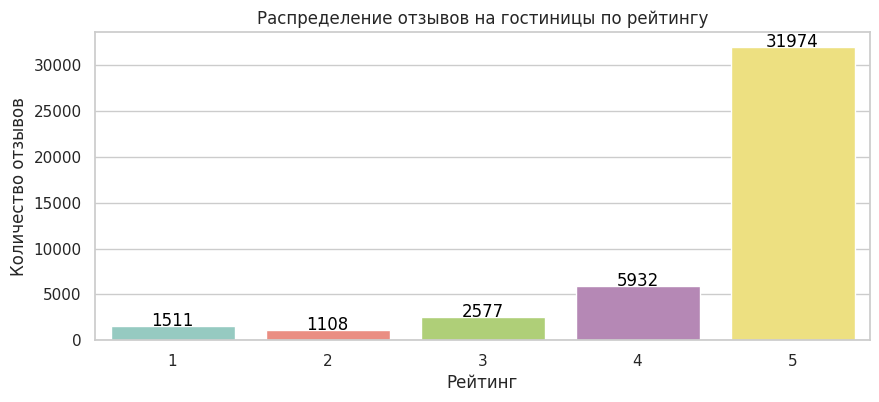

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Устанавливаем тему Seaborn для улучшения визуального стиля
sns.set(style="whitegrid")

# Подсчитаем распределение отзывов по рейтингу
rating_distribution = df_hotels_reviews['rating'].value_counts().sort_index()

# Создаем DataFrame для удобства работы с Seaborn
df_rating_distribution = pd.DataFrame({'Rating': rating_distribution.index, 'Count': rating_distribution.values})

# Определение цветовой палитры для использования в обеих диаграммах
colors = plt.cm.Set3(np.linspace(0, 1, len(rating_distribution)))

# Построим график распределения отзывов по рейтингу с использованием одной палитры
plt.figure(figsize=(10, 4))
barplot = sns.barplot(x='Rating', y='Count', data=df_rating_distribution, palette=colors)

# Добавляем аннотации над каждым столбцом
for index, row in df_rating_distribution.iterrows():
    barplot.text(row.name, row.Count + 1, row.Count, color='black', ha="center")

plt.title('Распределение отзывов на гостиницы по рейтингу')
plt.xlabel('Рейтинг')
plt.ylabel('Количество отзывов')
plt.xticks(rotation=0)
plt.show()

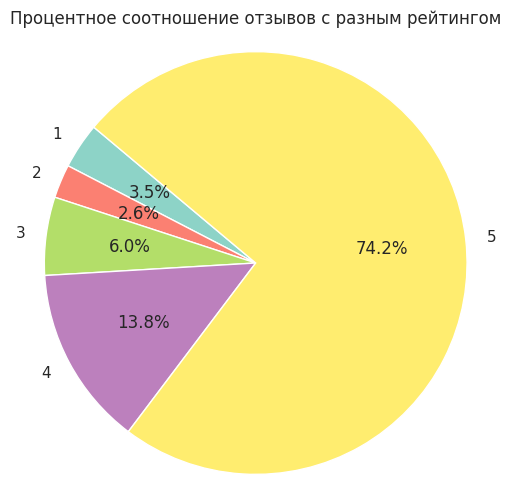

In [5]:
# Построим круговую диаграмму с той же цветовой палитрой
plt.figure(figsize=(6, 6))
plt.pie(rating_distribution, labels=rating_distribution.index, autopct='%1.1f%%', startangle=140, colors=colors)
plt.title('Процентное соотношение отзывов с разным рейтингом')
plt.axis('equal')  # Это делает круг кругом (а не овалом)
plt.show()

## Разделение датафрейма в зависимости от рейтинга

In [6]:
# Разделим данные в зависимости от рейтинга (высокий - 5, средний - 4, низкий - 1,2,3)
high_rating_reviews = df_hotels_reviews[df_hotels_reviews['rating'].isin([5])]
mid_rating_reviews = df_hotels_reviews[df_hotels_reviews['rating'].isin([4])]
low_rating_reviews = df_hotels_reviews[df_hotels_reviews['rating'].isin([1, 2, 3])]

In [7]:
# Сгруппируем тексты отзывов в одну строку для дальнейшей обработки и анализа
high_rating_reviews_text = " ".join(review for review in high_rating_reviews['text'])
mid_rating_reviews_text = " ".join(review for review in mid_rating_reviews['text'])
low_rating_reviews_text = " ".join(review for review in low_rating_reviews['text'])

## Анализ частоты слов в тексте отзывов

In [8]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from collections import defaultdict
import pymorphy2
from collections import Counter

# Инициализация кэша лемм в виде словаря, где ключом является исходное слово, а значением — его лемма.
lemma_cache = defaultdict(lambda: None)

# Создание экземпляра MorphAnalyzer для морфологического анализа слов при лемматизации
morph = pymorphy2.MorphAnalyzer()

# Функция токенизации
# Преобразует входной текст в список слов (токенов), приведя все слова к нижнему регистру.
def tokenize_text(text):
    return word_tokenize(text.lower())

# Функция фильтрации
# Фильтрует список слов, исключая слова содержащие неалфавитные символы, цифры и стоп-слова
def filter_words(words, stop_words, prefix_words):
    filtered_words = [word for word in words if word.isalnum() and not any(char.isdigit() for char in word) and word not in stop_words and not any(word.startswith(prefix) for prefix in prefix_words)]
    return filtered_words

# Функция лемматизации
# Применяет лемматизацию к списку слов, приводя их к базовой форме (лемме).
def lemmatize_words(words, morph):
    lemmatized_words = []
    for word in words:
        if lemma_cache[word] is None:  # Проверка наличия слова в кэше лемм. Перед выполнением лемматизации проверяется, существует ли уже лемма для данного слова в кэше
            lemma_cache[word] = morph.parse(word)[0].normal_form
        lemmatized_words.append(lemma_cache[word])
    return lemmatized_words 

# Функция подсчета частоты слов
# Подсчитывает частоту каждого слова в списке и возвращает отсортированный список слов по убыванию частоты.
def counter_words(words):
    words_count = Counter(words)
    sorted_words_count = sorted(words_count.items(), key=lambda item: item[1], reverse=True)
    return sorted_words_count

# Итоговая функция обработки текста
# Обрабатывает текст в 4 этапа: 1.Токенизация, 2.Фильтрация, 3.Лемматизация, 4.Подсчет частоты слов
def process_text(text, morph, stop_words, prefix_words):
    tokenized_text = tokenize_text(text)
    filtered_text = filter_words(tokenized_text, stop_words, prefix_words)
    lemmatized_text = lemmatize_words(filtered_text, morph)
    result = counter_words(lemmatized_text)
    return dict(result)   # Возвращаем словарь слово:частота

# Подключаем стоп-слова для русского языка
stop_words = set(stopwords.words('russian'))

# Дополнительные исключения слов
additional_stop_words = ["это", "всё", "просто", "очень", "хотя", "ещё", "вообще", "нам", "также", "целом", "поэтому", "которые", "который"]
stop_words.update(additional_stop_words)

# Префиксы слов которые нужно исключить
prefix_words = ["номер", "отел", "гостини"]

In [9]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Функция для создания и отображения облака слов из словаря с частотой слов
def create_wordcloud(words_count, title, fontsize=16):
    # Создаем облако слов
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate_from_frequencies(words_count)
    # Отображаем облако слов
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title, fontsize=fontsize)
    plt.show()    

In [10]:
high_rating_reviews_words_count = process_text(high_rating_reviews_text, morph, stop_words, prefix_words)

high_rating_reviews_unique_words_count = len(high_rating_reviews_words_count)
print(f"Количество уникальных слов в отзывах с высоким рейтингом: {high_rating_reviews_unique_words_count}")

print("Частота слов в отзывах с высоким рейтингом:")
high_rating_reviews_words_count

Количество уникальных слов в отзывах с высоким рейтингом: 28646
Частота слов в отзывах с высоким рейтингом:


{'хороший': 12023,
 'персонал': 11852,
 'отличный': 10235,
 'завтрак': 10097,
 'место': 9525,
 'чистый': 9091,
 'уютный': 8694,
 'чисто': 7606,
 'понравиться': 7232,
 'бассейн': 6426,
 'вкусный': 6343,
 'отдых': 5812,
 'весь': 5750,
 'рекомендовать': 5625,
 'удобный': 5452,
 'день': 5407,
 'спасибо': 5283,
 'территория': 5178,
 'рядом': 5109,
 'ребёнок': 5071,
 'вежливый': 4787,
 'расположение': 4569,
 'вид': 4503,
 'ресторан': 4482,
 'прекрасный': 4287,
 'большой': 4250,
 'море': 3954,
 'приветливый': 3934,
 'приятный': 3807,
 'еда': 3755,
 'кухня': 3699,
 'отдыхать': 3613,
 'каждый': 3597,
 'минута': 3483,
 'цена': 3432,
 'вкусно': 3417,
 'центр': 3408,
 'необходимый': 3400,
 'этаж': 3377,
 'вода': 3299,
 'дом': 3253,
 'свой': 3243,
 'больший': 3165,
 'стол': 3033,
 'кафе': 3017,
 'красивый': 2979,
 'полотенце': 2958,
 'кровать': 2933,
 'парковка': 2778,
 'город': 2745,
 'душа': 2674,
 'новый': 2522,
 'холодильник': 2503,
 'год': 2499,
 'окно': 2481,
 'останавливаться': 2466,
 'комфо

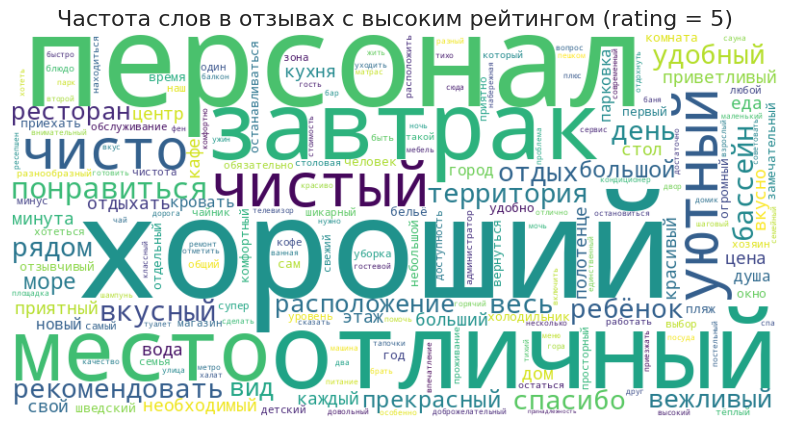

In [11]:
# Создадим облако частоты слов в отзывах с высоким рейтингом
create_wordcloud(high_rating_reviews_words_count, 'Частота слов в отзывах с высоким рейтингом (rating = 5)')

In [12]:
mid_rating_reviews_words_count = process_text(mid_rating_reviews_text, morph, stop_words, prefix_words)

mid_rating_reviews_unique_words_count = len(mid_rating_reviews_words_count)
print(f"Количество уникальных слов в отзывах с средним рейтингом: {mid_rating_reviews_unique_words_count}")

print("Частота слов в отзывах с средним рейтингом:")
mid_rating_reviews_words_count

Количество уникальных слов в отзывах с средним рейтингом: 15392
Частота слов в отзывах с средним рейтингом:


{'хороший': 3046,
 'завтрак': 2504,
 'персонал': 1916,
 'место': 1540,
 'чистый': 1455,
 'день': 1419,
 'чисто': 1375,
 'минус': 1339,
 'бассейн': 1269,
 'вода': 1213,
 'этаж': 1106,
 'ребёнок': 1076,
 'расположение': 1061,
 'рядом': 1045,
 'ресторан': 1042,
 'понравиться': 984,
 'отличный': 968,
 'территория': 955,
 'окно': 949,
 'удобный': 925,
 'кровать': 924,
 'цена': 920,
 'один': 883,
 'еда': 876,
 'вкусный': 866,
 'вид': 831,
 'уютный': 824,
 'стол': 803,
 'большой': 801,
 'полотенце': 784,
 'работать': 769,
 'маленький': 754,
 'больший': 731,
 'вежливый': 704,
 'центр': 703,
 'плюс': 702,
 'комната': 698,
 'душа': 688,
 'свой': 684,
 'кафе': 681,
 'звезда': 678,
 'парковка': 631,
 'каждый': 631,
 'человек': 627,
 'весь': 621,
 'приветливый': 620,
 'такой': 601,
 'минута': 598,
 'холодильник': 591,
 'кухня': 590,
 'первый': 576,
 'ночь': 576,
 'отдых': 574,
 'время': 570,
 'сам': 568,
 'приятный': 562,
 'общий': 556,
 'небольшой': 550,
 'море': 544,
 'шведский': 540,
 'бельё': 5

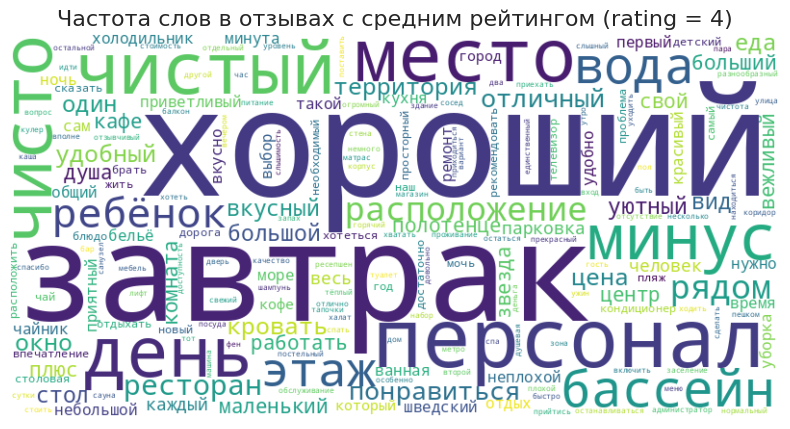

In [13]:
# Создадим облако частоты слов в отзывах с средним рейтингом
create_wordcloud(mid_rating_reviews_words_count, 'Частота слов в отзывах с средним рейтингом (rating = 4)')

In [14]:
low_rating_reviews_words_count = process_text(low_rating_reviews_text, morph, stop_words, prefix_words)

low_rating_reviews_unique_words_count = len(low_rating_reviews_words_count)
print(f"Количество уникальных слов в отзывах с низким рейтингом: {low_rating_reviews_unique_words_count}")

print("Частота слов в отзывах с низким рейтингом:")
low_rating_reviews_words_count

Количество уникальных слов в отзывах с низким рейтингом: 18651
Частота слов в отзывах с низким рейтингом:


{'день': 1859,
 'завтрак': 1793,
 'вода': 1652,
 'хороший': 1614,
 'место': 1445,
 'один': 1322,
 'ребёнок': 1313,
 'такой': 1274,
 'персонал': 1217,
 'сказать': 1169,
 'работать': 1142,
 'человек': 1117,
 'кровать': 1079,
 'бассейн': 1078,
 'этаж': 1061,
 'окно': 1015,
 'плюс': 1008,
 'весь': 990,
 'цена': 982,
 'сам': 949,
 'маленький': 916,
 'еда': 894,
 'полотенце': 867,
 'ресторан': 856,
 'ночь': 832,
 'который': 832,
 'администратор': 816,
 'территория': 807,
 'свой': 805,
 'душа': 803,
 'вид': 784,
 'чистый': 783,
 'первый': 780,
 'комната': 779,
 'время': 775,
 'звезда': 768,
 'час': 743,
 'стол': 715,
 'минус': 697,
 'деньга': 685,
 'гость': 668,
 'дверь': 667,
 'мочь': 661,
 'другой': 657,
 'нужно': 652,
 'расположение': 636,
 'общий': 636,
 'рядом': 633,
 'год': 629,
 'самый': 623,
 'никто': 600,
 'ванная': 596,
 'ресепшен': 590,
 'грязный': 586,
 'наш': 582,
 'приехать': 577,
 'бельё': 575,
 'хотеть': 565,
 'чисто': 562,
 'каждый': 554,
 'минута': 553,
 'отдых': 551,
 'стои

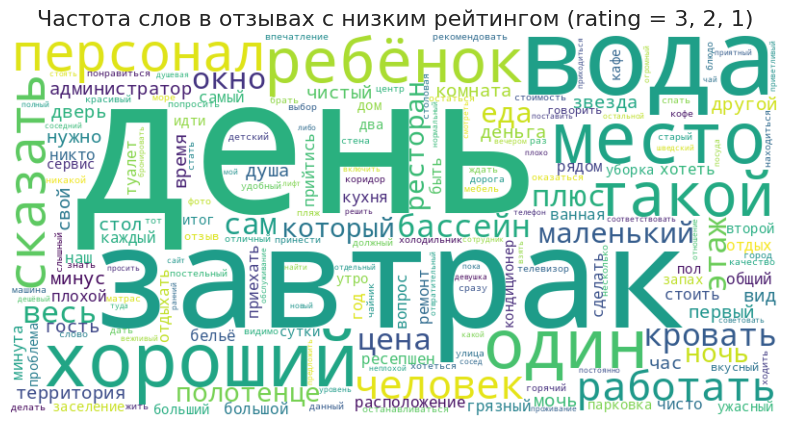

In [15]:
# Создадим облако частоты слов в отзывах с низким рейтингом
create_wordcloud(low_rating_reviews_words_count, 'Частота слов в отзывах с низким рейтингом (rating = 3, 2, 1)')

## Поиск слов специфичных для отзывов определенного рейтинга

In [16]:
# Находим слова специфичные для отзывов с высоким рейтингом (слово присутствуют в отзывах с высоким рейтингом и отсутствует в отзывх с низким рейтингом)
high_rating_reviews_specific_words_count = {word: count for word, count in high_rating_reviews_words_count.items() if word not in low_rating_reviews_words_count and count > 3}
# Осортируем специфичные слова для отзывов с высоким рейтингом по частоте
high_rating_reviews_specific_words_count = dict(sorted(high_rating_reviews_specific_words_count.items(), key=lambda x: x[1], reverse=True))

# Находим слова специфичные для отзывов с низким рейтингом (слово присутствуют в отзывах с низким рейтингом и отсутствует в отзывх с высоким рейтингом)
low_rating_reviews_specific_words_count = {word: count for word, count in low_rating_reviews_words_count.items() if word not in high_rating_reviews_words_count and count > 3}
# Осортируем специфичные слова для отзывов с низким рейтингом по частоте
low_rating_reviews_specific_words_count = dict(sorted(low_rating_reviews_specific_words_count.items(), key=lambda x: x[1], reverse=True))

In [17]:
print("Специфичные слова для отзывов с высоким рейтингом:")
high_rating_reviews_specific_words_count

Специфичные слова для отзывов с высоким рейтингом:


{'безупречный': 81,
 'немаловажный': 75,
 'обожать': 70,
 'искренний': 55,
 'покорить': 53,
 'суперский': 53,
 'завораживать': 52,
 'прогадать': 49,
 'божественный': 47,
 'эрмитаж': 44,
 'превосходно': 42,
 'перезагрузка': 41,
 'михаил': 40,
 'ценный': 39,
 'безупречно': 39,
 'бомбический': 38,
 'благополучие': 37,
 'винный': 37,
 'николай': 36,
 'разнообразить': 35,
 'угощать': 33,
 'незначительный': 33,
 'свежайший': 31,
 'денис': 31,
 'облизать': 31,
 'паб': 29,
 'апельсиновый': 29,
 'тенистый': 27,
 'шатлы': 27,
 'вдоволь': 26,
 'мюсли': 26,
 'умиротворение': 26,
 'творческий': 26,
 'открытка': 26,
 'энергетика': 25,
 'ухоженый': 25,
 'неограниченный': 25,
 'прибой': 24,
 'самовар': 24,
 'паралия': 24,
 'павел': 24,
 'уточка': 24,
 'кристально': 24,
 'развить': 24,
 'заряд': 23,
 'гармонично': 23,
 'порыбачить': 23,
 'раздолье': 23,
 'жарковатый': 23,
 'сбербанк': 23,
 'заснеженный': 22,
 'шторм': 22,
 'саратов': 22,
 'необыкновенно': 22,
 'восхитительно': 22,
 'добротно': 22,
 'му

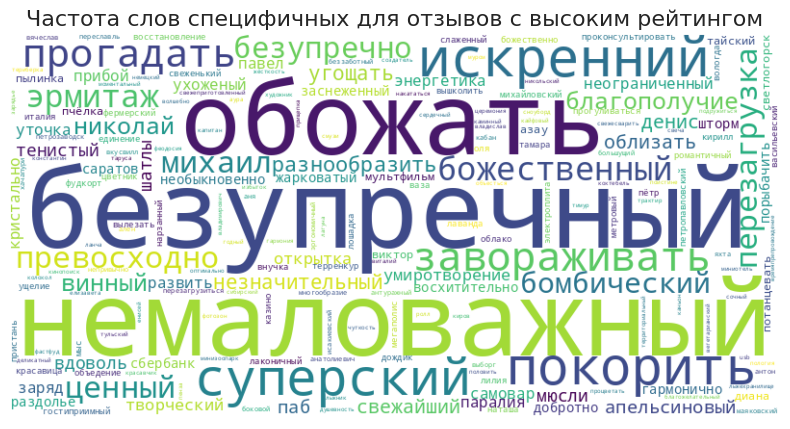

In [18]:
# Создадим облако частоты слов специфичных для отзывов с высоким рейтингом
create_wordcloud(high_rating_reviews_specific_words_count, 'Частота слов специфичных для отзывов с высоким рейтингом')

In [19]:
print("Специфичные слова для отзывов с низким рейтингом:")
low_rating_reviews_specific_words_count

Специфичные слова для отзывов с низким рейтингом:


{'дыра': 35,
 'помойка': 30,
 'треш': 27,
 'протереть': 22,
 'прождать': 21,
 'удосужиться': 18,
 'нахамить': 16,
 'неуважение': 16,
 'позор': 16,
 'мытый': 14,
 'наплевательский': 14,
 'попытаться': 14,
 'немытый': 13,
 'вырвать': 12,
 'сонный': 11,
 'ободок': 10,
 'чековый': 10,
 'переселять': 10,
 'задохнуться': 10,
 'отклеиваться': 9,
 'жижа': 9,
 'комнатушка': 9,
 'гастарбайтер': 9,
 'некомпетентный': 9,
 'хрен': 9,
 'рвота': 8,
 'клочок': 8,
 'следовательно': 8,
 'молоток': 8,
 'мокрица': 8,
 'хамски': 8,
 'притон': 8,
 'прокиснуть': 8,
 'бомж': 8,
 'перечёркивать': 7,
 'мочить': 7,
 'выпросить': 7,
 'неоднократный': 7,
 'полумрак': 7,
 'посмеяться': 7,
 'заклеить': 7,
 'несчастный': 7,
 'выветриваться': 7,
 'хамть': 7,
 'свинство': 7,
 'вздох': 7,
 'старик': 7,
 'герметик': 7,
 'пытка': 7,
 'битый': 7,
 'нюхать': 7,
 'помои': 7,
 'ветхий': 7,
 'орган': 7,
 'клоповник': 7,
 'фу': 7,
 'издевательство': 7,
 'резина': 7,
 'накидать': 7,
 'обвинять': 7,
 'несвежий': 7,
 'пересилить':

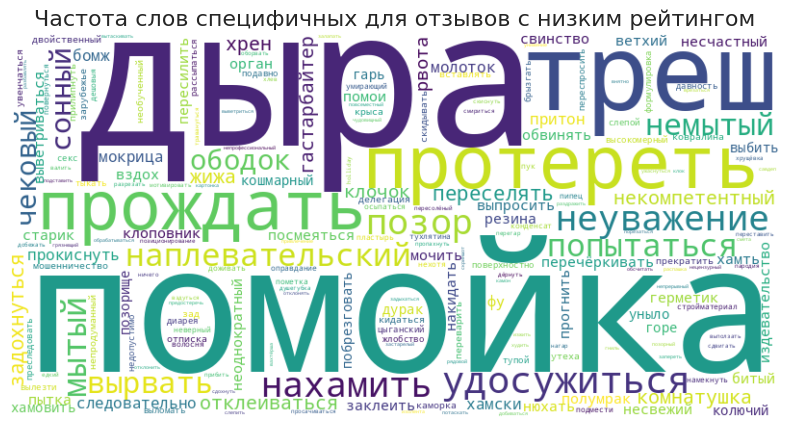

In [20]:
# Создадим облако частоты слов специфичных для отзывов с низким рейтингом
create_wordcloud(low_rating_reviews_specific_words_count, 'Частота слов специфичных для отзывов с низким рейтингом')